In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("mall.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df=df.drop(columns=["CustomerID","Genre"])

In [4]:
x=df.iloc[:,[0,1]].values

In [5]:
from sklearn.cluster import KMeans

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

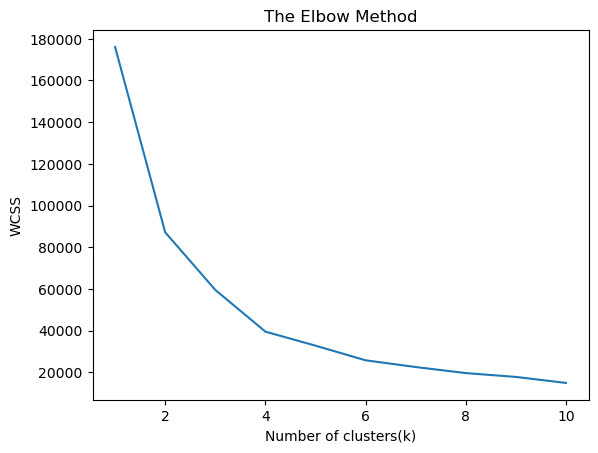

In [6]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)

plt.title("The Elbow Method")
plt.xlabel("Number of clusters(k)")
plt.ylabel("WCSS")
plt.show()


###FROM THE ABOVE PLOT, WE CAN SEE THE ELBOW POINT IS AT 4. SO THE NUMBER OF CLUSTERS HERE WILL BE 4.

In [7]:
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)
y_predict=kmeans.fit_predict(x)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


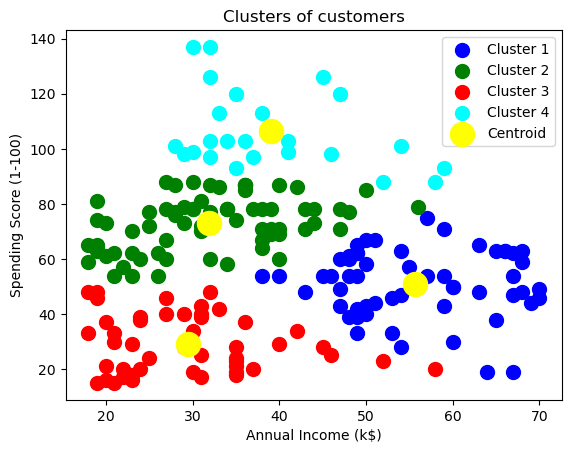

In [8]:
 #Initializing the clusters
 plt.scatter(x[y_predict==0,0],x[y_predict==0,1],s=100,c='blue',label="Cluster 1") #for first cluster
 plt.scatter(x[y_predict==1,0],x[y_predict==1,1],s=100,c='green',label="Cluster 2") #for second cluster
 plt.scatter(x[y_predict==2,0],x[y_predict==2,1],s=100,c='red',label="Cluster 3") #for third cluster
 plt.scatter(x[y_predict==3,0],x[y_predict==3,1],s=100,c='cyan',label="Cluster 4") #for fourth cluster

 plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',label="Centroid") #for centroids

 plt.title("Clusters of customers")
 plt.xlabel("Annual Income (k$)")
 plt.ylabel("Spending Score (1-100)")
 plt.legend()
 plt.show()